# 02 — Multi-CW Pulsar Distance Recovery Lab

Inline notebook for the actual optimization experiment:

1. choose `N_PSR` pulsars, sorted by tightest EM distance priors
2. inject `N_CW` continuous waves into those pulsars
3. build matching likelihood
4. optimize only pulsar distances by repeated 2D scans over pulsar pairs
5. visualize convergence, pair-scan surfaces, and per-pulsar recovery

No command-line subprocess layer here. The notebook keeps the likelihood object, current distance vector, pair updates, and scan surfaces visible.

In [70]:
from pathlib import Path
import sys
import time
import itertools
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output, display

HERE = Path.cwd()
sys.path.insert(0, str((HERE / "../CW_lnL_check").resolve()))

from cw_helpers import (
    build_disco_likelihood,
    build_enterprise_pta,
    build_pure_cw_likelihood,
    compute_mode_spacing,
    generate_injection_params,
    inject_noisefree_cw,
    load_pulsars,
    scan_pair_window_2d,
    scan_pulsar_distance,
    scan_pulsar_pair_2d,
    simulate,
)

print(HERE)

/home/mattm/projects/HSYMT/lnL_distance_scans


## Control Panel

Start small. Once behavior is clear, increase `N_PSR`, `N_STARTS`, `MAX_SWEEPS`, and grid resolution.

Distance model now separates **injection truth** from the **EM prior mean**:

- `prior_mean = psr.pdist[0]` from the distance files / `get_distance` product
- `prior_sigma = psr.pdist[1]`
- `truth_dist` is drawn from or offset relative to that EM prior
- optimizer starts from prior draws or prior means, not from truth unless explicitly requested

`DATA_MODE="pure"`: noise-free CW-only debugging. Truth should be exact global maximum.

`DATA_MODE="stochastic"`: enterprise simulation injects white noise, intrinsic red noise, optional HD GWB, and CWs; discovery evaluates matching stochastic GP likelihood with noise hyperparameters fixed at injection truth.

In [ ]:
# PTA / injection knobs
DATA_MODE = "pure"            # "pure" or "stochastic"
N_PSR = 20                    # keep <=80 if using discovery HD GWB path
N_CW = 4
LOG10_H = -12.0
LOG10_MC = None               # None = use defaults below / generated params
RNG_SEED = 12345
NOISE_SEED = 24680

# Distance-truth knobs. EM prior remains (pdist[0], pdist[1]); injection truth can differ.
TRUTH_DISTANCE_MODE = "gaussian_prior_draw"  # "prior_mean", "gaussian_prior_draw", "sigma_offset"
TRUTH_SIGMA_OFFSET = 1.0       # used when TRUTH_DISTANCE_MODE == "sigma_offset"
TRUTH_SIGMA_CLIP = 3.0         # clip truth/start draws to mean +/- this many sigma

# Stochastic mode knobs
STOCHASTIC_SCENARIO = "well_separated"
COMPONENTS = 10               # 5-10 for quick tests, 30 for fuller runs
INCLUDE_GWB = True
GWB_LOG10_A = -17.5
GWB_GAMMA = 13/3

# Optimizer knobs. STARTS are independent deterministic optimizer restarts, not MCMC starts.
N_STARTS = 10
START_MODE = "random"         # "prior_mean", "random", "mean_plus_random"
MAX_SWEEPS = 4
PAIR_MODE = "anchor_ladder"     # "anchor", "anchor_ladder", "all"
MAX_PAIRS_PER_SWEEP = 0        # 0 = full schedule
HALF_WIDTH_MODES = 25.0
POINTS_PER_MODE = 1
MIN_POINTS = 61
CHUNK_SIZE = None
PRIOR_SIGMA_CLIP = 3.0
ACCEPT_TOL = 1e-8
CONVERGENCE_TOL = 0.1

# Display knobs
PLOT_DURING_RUN = False
PLOT_EVERY_PAIR = 5
KEEP_SCAN_SURFACES = 12        # keep last N pair surfaces for inspection

# Mode-candidate / beam optimizer knobs
MODE_PRIOR_SIGMA_WIDTH = 3.0   # candidate search interval around EM prior mean
MODE_SAMPLES_PER_MODE = 3      # 1D grid resolution relative to smallest mode spacing
MAX_1D_SCAN_POINTS = 2000      # cap per-pulsar 1D scan cost
TOP_MODE_CANDIDATES = 12       # candidate modes kept per pulsar
BEAM_WIDTH = 8                 # number of global distance hypotheses kept
BEAM_RANDOM_STATES = 16        # extra random candidate-combination states before pruning to beam
PAIR_CENTER_K = 5              # per-pulsar top candidate centers used in pair update
PAIR_LOCAL_HALF_WIDTH_MODES = 1.5
PAIR_LOCAL_POINTS_PER_MODE = 4
PAIR_LOCAL_MIN_POINTS = 9
BEAM_MAX_SWEEPS = 4


## Helper Functions

These are notebook-level orchestration functions. Heavy likelihood/scanning code remains in `cw_helpers.py` and is JIT/batched there.

In [72]:
CW_LIBRARY = [
    dict(cos_gwtheta=0.30, gwphi=2.50, cos_inc=-0.20, phase0=1.00, psi=0.70, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.00),
    dict(cos_gwtheta=-0.50, gwphi=0.80, cos_inc=0.40, phase0=2.10, psi=1.30, log10_h=-12.0, log10_mc=9.00, log10_fgw=-7.80),
    dict(cos_gwtheta=0.05, gwphi=4.20, cos_inc=-0.65, phase0=0.35, psi=2.30, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.20),
    dict(cos_gwtheta=0.70, gwphi=5.40, cos_inc=0.10, phase0=1.70, psi=0.20, log10_h=-12.0, log10_mc=9.00, log10_fgw=-7.90),
    dict(cos_gwtheta=-0.10, gwphi=3.30, cos_inc=0.80, phase0=2.90, psi=1.80, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.10),
]


def select_pulsars(n_psr):
    ent_all, disco_all = load_pulsars(None)
    pairs = sorted(zip(ent_all, disco_all), key=lambda pair: pair[1].pdist[1])
    selected = pairs[:n_psr]
    ent_psrs = [p[0] for p in selected]
    disco_psrs = [p[1] for p in selected]
    return ent_psrs, disco_psrs, len(disco_all)


def clipped_normal(mean, sigma, rng, clip):
    draw = rng.normal(mean, sigma)
    lo = np.maximum(0.01, mean - clip * sigma)
    hi = mean + clip * sigma
    return np.clip(draw, lo, hi)


def make_truth_distances(prior_mean, prior_sigma, rng):
    if TRUTH_DISTANCE_MODE == "prior_mean":
        return prior_mean.copy()
    if TRUTH_DISTANCE_MODE == "gaussian_prior_draw":
        return clipped_normal(prior_mean, prior_sigma, rng, TRUTH_SIGMA_CLIP)
    if TRUTH_DISTANCE_MODE == "sigma_offset":
        signs = rng.choice([-1.0, 1.0], size=len(prior_mean))
        return np.maximum(0.01, prior_mean + signs * TRUTH_SIGMA_OFFSET * prior_sigma)
    raise ValueError(TRUTH_DISTANCE_MODE)


def clone_psrs_with_distances(psrs, distances):
    clones = copy.deepcopy(psrs)
    for psr, dist in zip(clones, distances):
        sigma = float(psr.pdist[1])
        try:
            psr.pdist = (float(dist), sigma)
        except Exception:
            # Some pulsar containers expose pdist as a property backed by _pdist.
            psr._pdist = (float(dist), sigma)
    return clones


def cw_params_from_library(n_cw, log10_h=None, log10_mc=None):
    if n_cw > len(CW_LIBRARY):
        raise ValueError(f"N_CW={n_cw} exceeds CW_LIBRARY size={len(CW_LIBRARY)}")
    out = [dict(cw) for cw in CW_LIBRARY[:n_cw]]
    for cw in out:
        if log10_h is not None:
            cw["log10_h"] = log10_h
        if log10_mc is not None:
            cw["log10_mc"] = log10_mc
    return out


def cw_list_from_enterprise_params(enterprise_params, cw_block_names):
    keys = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw", "log10_h", "phase0", "psi")
    return [{key: float(enterprise_params[f"{name}_{key}"]) for key in keys} for name in cw_block_names]


def make_pair_schedule(n_psr, mode):
    if mode == "all":
        return [(i, j) for i in range(n_psr) for j in range(i + 1, n_psr)]
    if mode == "anchor":
        return [(0, j) for j in range(1, n_psr)]
    if mode == "anchor_ladder":
        pairs = [(0, j) for j in range(1, n_psr)]
        pairs += [(j, j + 1) for j in range(1, n_psr - 1)]
        return list(dict.fromkeys(pairs))
    raise ValueError(mode)


def distance_key(psr):
    return f"{psr.name}_cw_p_dist"


def get_distances(values, param_keys, disco_psrs):
    return np.array([float(values[param_keys.index(distance_key(psr))]) for psr in disco_psrs])


def set_distances(values, param_keys, disco_psrs, distances):
    out = np.array(values, dtype=float).copy()
    for psr, dist in zip(disco_psrs, distances):
        out[param_keys.index(distance_key(psr))] = dist
    return out


def draw_initial_distances(disco_psrs, rng, kind):
    means = np.array([p.pdist[0] for p in disco_psrs], dtype=float)
    sigmas = np.array([p.pdist[1] for p in disco_psrs], dtype=float)
    if kind == "prior_mean":
        return means.copy()
    if kind == "random":
        return clipped_normal(means, sigmas, rng, PRIOR_SIGMA_CLIP)
    raise ValueError(kind)


def min_mode_spacings(disco_psrs, cw_params_list):
    out = []
    for psr in disco_psrs:
        vals = [compute_mode_spacing(cw["cos_gwtheta"], cw["gwphi"], cw["log10_fgw"], psr.pos) for cw in cw_params_list]
        out.append(float(np.nanmin(vals)))
    return np.array(out)


def recovery_score(distances, truth_dist, sigmas, mode_spacings):
    err = distances - truth_dist
    return dict(
        max_abs_kpc=float(np.nanmax(np.abs(err))),
        median_abs_kpc=float(np.nanmedian(np.abs(err))),
        max_abs_sigma=float(np.nanmax(np.abs(err / sigmas))),
        median_abs_sigma=float(np.nanmedian(np.abs(err / sigmas))),
        max_abs_modes=float(np.nanmax(np.abs(err / mode_spacings))),
        median_abs_modes=float(np.nanmedian(np.abs(err / mode_spacings))),
        frac_within_half_mode=float(np.nanmean(np.abs(err / mode_spacings) < 0.5)),
        frac_within_one_mode=float(np.nanmean(np.abs(err / mode_spacings) < 1.0)),
    )


def plot_start_status(history_df, latest_dist=None, truth_dist=None, mode_spacings=None):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if len(history_df):
        for start, sub in history_df.groupby("start"):
            sub = sub.sort_values("step")
            axes[0].plot(sub["step"], sub["lnL"], ".-", label=f"start {start}")
            axes[1].plot(sub["step"], sub["frac_within_half_mode"], ".-", label=f"start {start}")
            axes[2].plot(sub["step"], sub["median_abs_modes"], ".-", label=f"start {start}")
    axes[0].set_ylabel("lnL")
    axes[1].set_ylabel("fraction within 0.5 mode")
    axes[2].set_ylabel("median |distance error| / mode")
    axes[2].set_yscale("log")
    for ax in axes:
        ax.set_xlabel("pair update step")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def set_pair_plot_limits(ax, grid_i, grid_j, truth_i, truth_j, pad_frac=0.05):
    xvals = np.asarray(list(grid_j) + [truth_j], dtype=float)
    yvals = np.asarray(list(grid_i) + [truth_i], dtype=float)
    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)
    xpad = max((xmax - xmin) * pad_frac, 1e-9)
    ypad = max((ymax - ymin) * pad_frac, 1e-9)
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)


def draw_truth_crosshair(ax, truth_i, truth_j, **kwargs):
    # Two-pass line: black underlay + magenta overlay stays visible on both
    # dark likelihood maps and white unexplored margins.
    under = dict(color="black", lw=3.0, ls="--", alpha=0.9, zorder=8)
    over = dict(color="magenta", lw=1.6, ls="--", alpha=0.95, zorder=9, label="truth")
    under.update({k: v for k, v in kwargs.items() if k != "label"})
    over.update(kwargs)
    ax.axvline(truth_j, **under)
    ax.axhline(truth_i, **under)
    ax.axvline(truth_j, **over)
    over_no_label = dict(over)
    over_no_label.pop("label", None)
    ax.axhline(truth_i, **over_no_label)


def top_local_maxima(x, y, k):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    x, y = x[finite], y[finite]
    if len(x) == 0:
        return np.array([]), np.array([])
    if len(x) >= 3:
        peak_mask = np.r_[False, (y[1:-1] >= y[:-2]) & (y[1:-1] >= y[2:]), False]
        idx = np.where(peak_mask)[0]
    else:
        idx = np.array([], dtype=int)
    if len(idx) < k:
        extra_idx = np.argsort(y)[::-1]
        idx = np.unique(np.r_[idx, extra_idx])
    idx = idx[np.argsort(y[idx])[::-1]][:k]
    return x[idx], y[idx]


def candidate_grid_for_pulsar(psr, dL, prior_mean_i, sigma_i):
    lo = max(0.01, prior_mean_i - MODE_PRIOR_SIGMA_WIDTH * sigma_i)
    hi = prior_mean_i + MODE_PRIOR_SIGMA_WIDTH * sigma_i
    if not np.isfinite(dL) or dL <= 0:
        n_points = MAX_1D_SCAN_POINTS
    else:
        n_points = int(np.ceil((hi - lo) / dL * MODE_SAMPLES_PER_MODE)) + 1
        n_points = int(np.clip(n_points, 25, MAX_1D_SCAN_POINTS))
    return lo, hi, n_points


def make_local_grid_around_centers(centers, dL, lo, hi, half_width_modes, points_per_mode, min_points):
    centers = np.asarray(centers, dtype=float)
    centers = centers[np.isfinite(centers)]
    if len(centers) == 0:
        return np.linspace(lo, hi, min_points)
    half = half_width_modes * dL if np.isfinite(dL) and dL > 0 else 0.1 * (hi - lo)
    n = int(max(min_points, np.ceil(2 * half_width_modes * points_per_mode + 1)))
    pieces = []
    for c in centers:
        a = max(lo, c - half)
        b = min(hi, c + half)
        if b > a:
            pieces.append(np.linspace(a, b, n))
        else:
            pieces.append(np.array([np.clip(c, lo, hi)]))
    return np.unique(np.concatenate(pieces))


def dedupe_beam(states, mode_spacings, max_states):
    seen = set()
    out = []
    for st in sorted(states, key=lambda s: s["lnL"], reverse=True):
        key = tuple(np.round(st["distances"] / mode_spacings, 2))
        if key in seen:
            continue
        seen.add(key)
        out.append(st)
        if len(out) >= max_states:
            break
    return out


## Build Injection and Likelihood

This cell constructs data and likelihood once. The first likelihood call warms JIT.

In [73]:
rng = np.random.default_rng(RNG_SEED)
np.random.seed(NOISE_SEED)

t0 = time.time()
ent_psrs, disco_psrs, total_loaded = select_pulsars(N_PSR)
prior_mean = np.array([p.pdist[0] for p in disco_psrs], dtype=float)
sigmas = np.array([p.pdist[1] for p in disco_psrs], dtype=float)
truth_dist = make_truth_distances(prior_mean, sigmas, rng)

# Injection pulsars carry the true distances. Likelihood pulsars keep EM prior means.
ent_psrs_inj = clone_psrs_with_distances(ent_psrs, truth_dist)
disco_psrs_inj = clone_psrs_with_distances(disco_psrs, truth_dist)

if DATA_MODE == "pure":
    cw_params_list = cw_params_from_library(N_CW, log10_h=LOG10_H, log10_mc=LOG10_MC)
    residual_map, _ = inject_noisefree_cw(disco_psrs_inj, cw_params_list)
    logl_fn, param_keys, base_values = build_pure_cw_likelihood(disco_psrs, residual_map, cw_params_list)
    enterprise_params = None
    cw_block_names = None
else:
    pta, cw_block_names, _ = build_enterprise_pta(ent_psrs_inj, N_CW, components=COMPONENTS)
    enterprise_params = generate_injection_params(
        pta, ent_psrs_inj, N_CW, cw_block_names,
        log10_h=LOG10_H,
        scenario=STOCHASTIC_SCENARIO,
        rng=rng,
        gwb_log10_A=GWB_LOG10_A,
        gwb_gamma=GWB_GAMMA,
    )
    if LOG10_MC is not None:
        for name in cw_block_names:
            enterprise_params[f"{name}_log10_mc"] = LOG10_MC
    cw_params_list = cw_list_from_enterprise_params(enterprise_params, cw_block_names)
    sim_resids = simulate(pta, enterprise_params, sparse_cholesky=True)
    residual_map = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}
    logl_fn, param_keys, base_values = build_disco_likelihood(
        disco_psrs,
        residual_map,
        num_cw=N_CW,
        enterprise_params=enterprise_params,
        cw_block_names=cw_block_names,
        components=COMPONENTS,
        include_gwb=INCLUDE_GWB,
    )

mode_spacings = min_mode_spacings(disco_psrs, cw_params_list)
pair_schedule = make_pair_schedule(N_PSR, PAIR_MODE)
if MAX_PAIRS_PER_SWEEP:
    pair_schedule = pair_schedule[:MAX_PAIRS_PER_SWEEP]

prior_mean_values = np.array(base_values, dtype=float)
truth_values = set_distances(base_values, param_keys, disco_psrs, truth_dist)
prior_mean_lnL = float(logl_fn(prior_mean_values))
truth_lnL = float(logl_fn(truth_values))
if not np.isfinite(truth_lnL):
    raise RuntimeError("truth lnL is non-finite")

print(f"loaded pulsars total: {total_loaded}")
print(f"selected pulsars: {N_PSR} tightest distance priors")
print(f"data mode: {DATA_MODE}")
print(f"N_CW: {N_CW}")
print(f"truth distance mode: {TRUTH_DISTANCE_MODE}")
print(f"pairs per sweep: {len(pair_schedule)}")
print(f"truth lnL: {truth_lnL:.3f}")
print(f"prior-mean lnL: {prior_mean_lnL:.3f}  ΔlnL(prior mean - truth)={prior_mean_lnL - truth_lnL:.3f}")
print(f"mode spacing min/median/max [kpc]: {np.nanmin(mode_spacings):.3g} / {np.nanmedian(mode_spacings):.3g} / {np.nanmax(mode_spacings):.3g}")
print(f"build + JIT seconds: {time.time() - t0:.1f}")

pd.DataFrame({
    "pulsar": [p.name for p in disco_psrs],
    "prior_mean_kpc": prior_mean,
    "truth_kpc": truth_dist,
    "truth_minus_prior_sigma": (truth_dist - prior_mean) / sigmas,
    "sigma_kpc": sigmas,
    "min_mode_spacing_kpc": mode_spacings,
    "sigma_over_mode": sigmas / mode_spacings,
}).head(20)

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

,pulsar,prior_mean_kpc,truth_kpc,truth_minus_prior_sigma,sigma_kpc,min_mode_spacing_kpc,sigma_over_mode
0,J0437-4715,0.1549,0.153476,-1.423825,0.0010,0.000322,3.102466
1,J0030+0451,0.3296,0.334149,1.263728,0.0036,0.000376,9.580958
2,J1744-1134,0.4141,0.406003,-0.870662,0.0093,0.001356,6.858410
3,J1909-3744,1.1590,1.155631,-0.259173,0.0130,0.000627,20.739006
4,J1022+1001,0.7060,0.704568,-0.075343,0.0190,0.000494,38.432368
5,J1713+0747,1.1380,1.123923,-0.740885,0.0190,0.001527,12.445924
6,J0711-6830,0.1060,0.077003,-1.367793,0.0212,0.000381,55.700071
7,J1012+5307,0.8620,0.876276,0.648893,0.0220,0.000540,40.746960
8,J1730-2304,0.5290,0.536943,0.361058,0.0220,0.001104,19.930983
9,J2145-0750,0.6240,0.581037,-1.952863,0.0220,0.000501,43.901857


## Pairwise Coordinate-Ascent Optimizer

Each pair scan holds all other pulsar distances fixed at current chain values. The pair update uses local windows centered on current guesses, with width in units of each pulsar's smallest CW mode spacing.

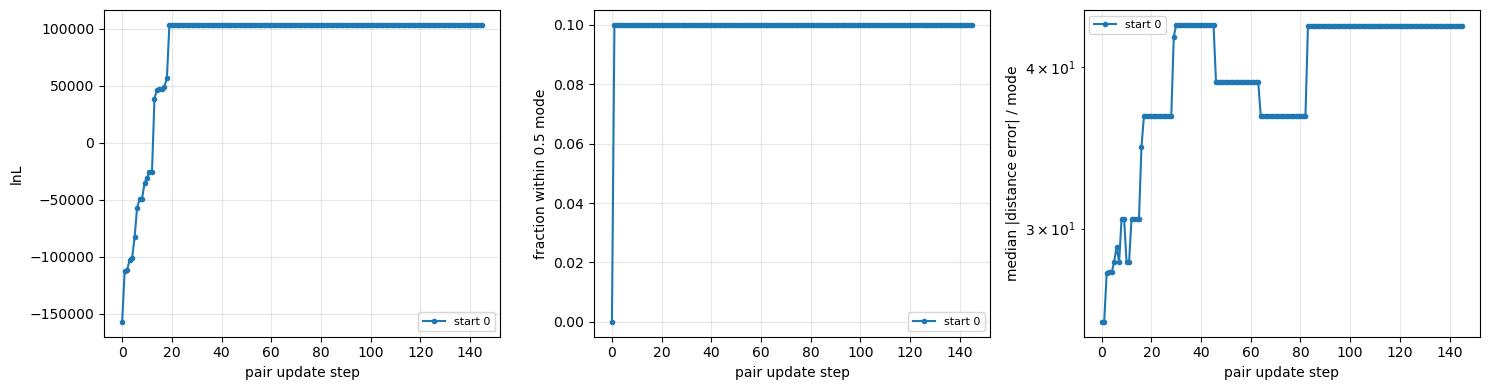

start 0 sweep 3 pair 34/37 lnL=103208.088
{'max_abs_kpc': 0.14317237457422727, 'median_abs_kpc': 0.03762636076392463, 'max_abs_sigma': 4.969375954757993, 'median_abs_sigma': 1.1648540733684127, 'max_abs_modes': 281.008262182335, 'median_abs_modes': 43.001572504063745, 'frac_within_half_mode': 0.1, 'frac_within_one_mode': 0.15}


KeyboardInterrupt: 

In [74]:
def run_inline_optimizer():
    start_kinds = []
    if START_MODE == "prior_mean":
        start_kinds = ["prior_mean"] * N_STARTS
    elif START_MODE == "random":
        start_kinds = ["random"] * N_STARTS
    elif START_MODE == "mean_plus_random":
        start_kinds = ["prior_mean"] + ["random"] * max(0, N_STARTS - 1)
    else:
        raise ValueError(START_MODE)

    all_history = []
    all_pair_records = []
    final_states = []

    for start_id, start_kind in enumerate(start_kinds):
        current_dist = draw_initial_distances(disco_psrs, rng, start_kind)
        current_values = set_distances(base_values, param_keys, disco_psrs, current_dist)
        current_lnL = float(logl_fn(current_values))
        step = 0
        stale = 0
        last_sweep_lnL = current_lnL

        score0 = recovery_score(current_dist, truth_dist, sigmas, mode_spacings)
        all_history.append(dict(start=start_id, sweep=-1, pair_index=-1, step=step, lnL=current_lnL, **score0))

        for sweep in range(MAX_SWEEPS):
            sweep_start_lnL = current_lnL
            for pair_index, (i, j) in enumerate(pair_schedule):
                psr_i, psr_j = disco_psrs[i], disco_psrs[j]
                current_dist = get_distances(current_values, param_keys, disco_psrs)
                old_lnL = float(logl_fn(current_values))

                scan = scan_pair_window_2d(
                    logl_fn,
                    current_values,
                    param_keys,
                    psr_i,
                    psr_j,
                    cw_params_list,
                    center_i=current_dist[i],
                    center_j=current_dist[j],
                    half_width_modes=HALF_WIDTH_MODES,
                    points_per_mode=POINTS_PER_MODE,
                    min_points=MIN_POINTS,
                    chunk_size=CHUNK_SIZE,
                    n_components=COMPONENTS,
                    include_truth=True,
                )

                new_values = np.array(current_values, dtype=float).copy()
                new_values[param_keys.index(distance_key(psr_i))] = scan["peak_i"]
                new_values[param_keys.index(distance_key(psr_j))] = scan["peak_j"]
                new_lnL = float(scan["peak_lnL"])
                accepted = new_lnL >= old_lnL - ACCEPT_TOL
                if accepted:
                    current_values = new_values
                    current_lnL = new_lnL
                else:
                    current_lnL = old_lnL

                step += 1
                current_dist = get_distances(current_values, param_keys, disco_psrs)
                sc = recovery_score(current_dist, truth_dist, sigmas, mode_spacings)
                all_history.append(dict(
                    start=start_id,
                    sweep=sweep,
                    pair_index=pair_index,
                    pair=f"{psr_i.name},{psr_j.name}",
                    step=step,
                    lnL=current_lnL,
                    accepted=accepted,
                    peak_lnL=new_lnL,
                    old_lnL=old_lnL,
                    dlnL=current_lnL - old_lnL,
                    **sc,
                ))

                all_pair_records.append(dict(
                    start=start_id,
                    sweep=sweep,
                    pair_index=pair_index,
                    step=step,
                    i=i,
                    j=j,
                    psr_i=psr_i.name,
                    psr_j=psr_j.name,
                    center_i=float(current_dist[i]),
                    center_j=float(current_dist[j]),
                    truth_i=float(truth_dist[i]),
                    truth_j=float(truth_dist[j]),
                    scan=scan,
                    accepted=accepted,
                ))
                if len(all_pair_records) > KEEP_SCAN_SURFACES:
                    all_pair_records = all_pair_records[-KEEP_SCAN_SURFACES:]

                if PLOT_DURING_RUN and (step % PLOT_EVERY_PAIR == 0):
                    hdf = pd.DataFrame(all_history)
                    plot_start_status(hdf)
                    print(f"start {start_id} sweep {sweep} pair {pair_index+1}/{len(pair_schedule)} lnL={current_lnL:.3f}")
                    print(sc)

            if abs(current_lnL - last_sweep_lnL) < CONVERGENCE_TOL:
                stale += 1
            else:
                stale = 0
            last_sweep_lnL = current_lnL
            if stale >= 2:
                break

        final_dist = get_distances(current_values, param_keys, disco_psrs)
        final_states.append(dict(
            start=start_id,
            start_kind=start_kind,
            values=current_values,
            distances=final_dist,
            lnL=float(logl_fn(current_values)),
            score=recovery_score(final_dist, truth_dist, sigmas, mode_spacings),
        ))

    return pd.DataFrame(all_history), all_pair_records, final_states

RUN_OPTIMIZER = True

if RUN_OPTIMIZER:
    history_df, pair_records, final_states = run_inline_optimizer()
else:
    print("Set RUN_OPTIMIZER=True in this cell to run inline pairwise scans.")

## Smarter Optimizer: Mode Candidates + Beam Search

This path is meant for cases where local pair scans get stuck far from truth.

It does three things:

1. Full-prior 1D pre-scan for each pulsar, keeping top candidate distance modes.
2. Builds a small beam of global distance hypotheses from candidate combinations.
3. For each pair update, scans 2D grids centered on candidate modes plus current beam value, then keeps top global states.

This is still deterministic brute-force optimization, not MCMC.

In [89]:
from cw_helpers import scan_pulsar_distance
def build_mode_candidates():
    candidate_rows = []
    candidates = []
    t0 = time.time()
    for i, psr in enumerate(disco_psrs):
        lo, hi, n_points = candidate_grid_for_pulsar(psr, mode_spacings[i], prior_mean[i], sigmas[i])
        vals, lls = scan_pulsar_distance(
            logl_fn,
            prior_mean_values,
            param_keys,
            distance_key(psr),
            lo,
            hi,
            n_points=n_points,
            chunk_size=CHUNK_SIZE,
            n_components=COMPONENTS,
            required_points=[prior_mean[i]],
        )
        cand_d, cand_ll = top_local_maxima(vals, lls, TOP_MODE_CANDIDATES)
        order = np.argsort(cand_ll)[::-1]
        cand_d, cand_ll = cand_d[order], cand_ll[order]
        candidates.append({"distances": cand_d, "lnL": cand_ll, "grid": vals, "grid_lnL": lls})
        for rank, (d, ll) in enumerate(zip(cand_d, cand_ll)):
            candidate_rows.append(dict(
                pulsar=psr.name,
                pulsar_index=i,
                rank=rank,
                distance=float(d),
                lnL=float(ll),
                delta_lnL=float(ll - np.nanmax(lls)),
                error_modes=float((d - truth_dist[i]) / mode_spacings[i]),
                error_sigma=float((d - truth_dist[i]) / sigmas[i]),
                n_points=n_points,
            ))
        print(f"{i+1:02d}/{len(disco_psrs)} {psr.name}: n_grid={n_points} best_err_modes={(cand_d[0]-truth_dist[i])/mode_spacings[i]:.3g}")
    print(f"candidate build seconds: {time.time() - t0:.1f}")
    return candidates, pd.DataFrame(candidate_rows)

RUN_CANDIDATE_SCAN = True

if RUN_CANDIDATE_SCAN:
    mode_candidates, candidate_df = build_mode_candidates()
else:
    print("Set RUN_CANDIDATE_SCAN=True to build per-pulsar mode candidates.")

01/20 J0437-4715: n_grid=57 best_err_modes=0.0961
02/20 J0030+0451: n_grid=174 best_err_modes=0.0208
03/20 J1744-1134: n_grid=298 best_err_modes=-0.134
04/20 J1909-3744: n_grid=375 best_err_modes=0.0516
05/20 J1022+1001: n_grid=693 best_err_modes=65.5
06/20 J1713+0747: n_grid=683 best_err_modes=0.0712
07/20 J0711-6830: n_grid=1004 best_err_modes=0.0498
08/20 J1012+5307: n_grid=735 best_err_modes=-101
09/20 J1730-2304: n_grid=603 best_err_modes=-42
10/20 J2145-0750: n_grid=811 best_err_modes=210
11/20 J1630+3734: n_grid=947 best_err_modes=-0.0361
12/20 J1614-2230: n_grid=608 best_err_modes=-40.5
13/20 J1737-0811: n_grid=1342 best_err_modes=0.0743
14/20 J1024-0719: n_grid=1464 best_err_modes=49.5
15/20 J2322-2650: n_grid=2000 best_err_modes=0.027
16/20 J2222-0137: n_grid=2000 best_err_modes=-139
17/20 J2124-3358: n_grid=2000 best_err_modes=-376
18/20 J1643-1224: n_grid=1668 best_err_modes=47.5
19/20 J0751+1807: n_grid=2000 best_err_modes=282
20/20 J1045-4509: n_grid=2000 best_err_modes=2

,pulsar,pulsar_index,rank,distance,lnL,delta_lnL,error_modes,error_sigma,n_points
0,J0437-4715,0,0,0.153507,-2.934025e+06,0.000000,0.096077,0.030968,57
1,J0437-4715,0,1,0.153400,-2.935052e+06,-1026.640094,-0.236330,-0.076175,57
2,J0437-4715,0,2,0.154364,-2.936646e+06,-2620.934170,2.755333,0.888111,57
3,J0437-4715,0,3,0.152543,-2.936715e+06,-2689.870151,-2.895586,-0.933318,57
4,J0437-4715,0,4,0.152650,-2.937644e+06,-3618.754323,-2.563179,-0.826175,57
...,...,...,...,...,...,...,...,...,...
228,J1045-4509,19,0,0.447052,-2.858344e+06,0.000000,21.189667,0.175308,2000
229,J1045-4509,19,1,0.407864,-2.858395e+06,-51.059958,-48.466844,-0.400980,2000
230,J1045-4509,19,2,0.172738,-2.858765e+06,-420.797195,-466.405913,-3.858709,2000
231,J1045-4509,19,3,0.389087,-2.858826e+06,-481.371973,-81.843923,-0.677118,2000


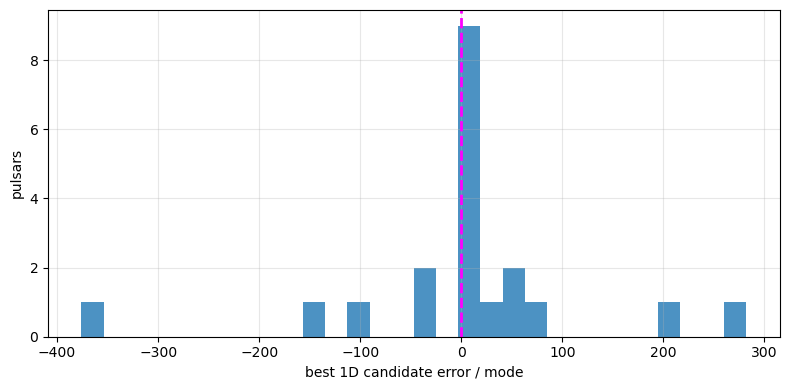

In [90]:
if "candidate_df" in globals() and len(candidate_df):
    display(candidate_df.groupby("pulsar").head(5))
    fig, ax = plt.subplots(figsize=(8, 4))
    best = candidate_df[candidate_df["rank"] == 0]
    ax.hist(best["error_modes"], bins=30, alpha=0.8)
    ax.axvline(0, color="magenta", ls="--", lw=2)
    ax.set_xlabel("best 1D candidate error / mode")
    ax.set_ylabel("pulsars")
    ax.grid(alpha=0.3)
    plt.tight_layout()
else:
    print("Build candidates first.")

In [91]:
from cw_helpers import scan_pulsar_pair_2d
def make_initial_beam(mode_candidates):
    states = []
    # best 1D candidate for every pulsar
    d_best = np.array([c["distances"][0] if len(c["distances"]) else prior_mean[i] for i, c in enumerate(mode_candidates)])
    for label, d in [("best_1d", d_best), ("prior_mean", prior_mean)]:
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=label, distances=d.copy(), values=vals, lnL=float(logl_fn(vals))))

    # random combinations from top candidates, weighted by relative 1D likelihood
    for rr in range(BEAM_RANDOM_STATES):
        d = []
        for i, c in enumerate(mode_candidates):
            cd = c["distances"]
            cl = c["lnL"]
            if len(cd) == 0:
                d.append(prior_mean[i])
                continue
            w = np.exp(cl - np.nanmax(cl))
            w = w / np.sum(w) if np.sum(w) > 0 else np.ones_like(w) / len(w)
            d.append(rng.choice(cd, p=w))
        d = np.array(d, dtype=float)
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=f"candidate_random_{rr}", distances=d, values=vals, lnL=float(logl_fn(vals))))
    return dedupe_beam(states, mode_spacings, BEAM_WIDTH)


def pair_candidate_update(state, i, j, mode_candidates):
    psr_i, psr_j = disco_psrs[i], disco_psrs[j]
    lo_i, hi_i, _ = candidate_grid_for_pulsar(psr_i, mode_spacings[i], prior_mean[i], sigmas[i])
    lo_j, hi_j, _ = candidate_grid_for_pulsar(psr_j, mode_spacings[j], prior_mean[j], sigmas[j])

    centers_i = [state["distances"][i], prior_mean[i]] + list(mode_candidates[i]["distances"][:PAIR_CENTER_K])
    centers_j = [state["distances"][j], prior_mean[j]] + list(mode_candidates[j]["distances"][:PAIR_CENTER_K])
    grid_i = make_local_grid_around_centers(centers_i, mode_spacings[i], lo_i, hi_i, PAIR_LOCAL_HALF_WIDTH_MODES, PAIR_LOCAL_POINTS_PER_MODE, PAIR_LOCAL_MIN_POINTS)
    grid_j = make_local_grid_around_centers(centers_j, mode_spacings[j], lo_j, hi_j, PAIR_LOCAL_HALF_WIDTH_MODES, PAIR_LOCAL_POINTS_PER_MODE, PAIR_LOCAL_MIN_POINTS)

    gi, gj, surf = scan_pulsar_pair_2d(
        logl_fn,
        state["values"],
        param_keys,
        distance_key(psr_i),
        distance_key(psr_j),
        grid_i,
        grid_j,
        chunk_size=CHUNK_SIZE,
        n_components=COMPONENTS,
    )
    mi, mj = np.unravel_index(np.nanargmax(surf), surf.shape)
    new_d = state["distances"].copy()
    new_d[i] = gi[mi]
    new_d[j] = gj[mj]
    new_vals = set_distances(state["values"], param_keys, disco_psrs, new_d)
    # surf was evaluated with same other params; peak value is valid.
    new_lnL = float(surf[mi, mj])
    return dict(
        label=state.get("label", "beam"),
        distances=new_d,
        values=new_vals,
        lnL=new_lnL,
        scan=dict(grid_i=gi, grid_j=gj, lnL=surf, peak_i=float(gi[mi]), peak_j=float(gj[mj]), peak_lnL=new_lnL),
    )


def run_beam_optimizer(mode_candidates):
    beam = make_initial_beam(mode_candidates)
    beam_history = []
    beam_pair_records = []
    step = 0
    for rank, st in enumerate(beam):
        sc = recovery_score(st["distances"], truth_dist, sigmas, mode_spacings)
        beam_history.append(dict(step=step, sweep=-1, pair_index=-1, rank=rank, lnL=st["lnL"], label=st["label"], **sc))

    for sweep in range(BEAM_MAX_SWEEPS):
        for pair_index, (i, j) in enumerate(pair_schedule):
            proposals = []
            for st in beam:
                proposals.append(pair_candidate_update(st, i, j, mode_candidates))
                # keep unmodified state too, in case pair update is harmful
                proposals.append({k: v for k, v in st.items() if k != "scan"})
            beam = dedupe_beam(proposals, mode_spacings, BEAM_WIDTH)
            step += 1
            for rank, st in enumerate(beam):
                sc = recovery_score(st["distances"], truth_dist, sigmas, mode_spacings)
                beam_history.append(dict(step=step, sweep=sweep, pair_index=pair_index, rank=rank, lnL=st["lnL"], label=st.get("label", "beam"), **sc))
            best = beam[0]
            beam_pair_records.append(dict(
                step=step,
                sweep=sweep,
                pair_index=pair_index,
                i=i,
                j=j,
                psr_i=disco_psrs[i].name,
                psr_j=disco_psrs[j].name,
                truth_i=float(truth_dist[i]),
                truth_j=float(truth_dist[j]),
                scan=best.get("scan"),
                best_lnL=best["lnL"],
                best_score=recovery_score(best["distances"], truth_dist, sigmas, mode_spacings),
            ))
            if PLOT_DURING_RUN and step % PLOT_EVERY_PAIR == 0:
                clear_output(wait=True)
                h = pd.DataFrame(beam_history)
                fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                best_h = h[h["rank"] == 0]
                axes[0].plot(best_h["step"], best_h["lnL"], ".-")
                axes[1].plot(best_h["step"], best_h["frac_within_half_mode"], ".-")
                axes[2].plot(best_h["step"], best_h["median_abs_modes"], ".-")
                axes[0].set_ylabel("best beam lnL")
                axes[1].set_ylabel("best beam frac within 0.5 mode")
                axes[2].set_ylabel("best beam median |err|/mode")
                axes[2].set_yscale("log")
                for ax in axes:
                    ax.set_xlabel("pair update step")
                    ax.grid(alpha=0.3)
                plt.tight_layout(); plt.show()
                print(f"sweep {sweep} pair {pair_index+1}/{len(pair_schedule)} best lnL={best['lnL']:.3f}")
                print(beam_pair_records[-1]["best_score"])
    return beam, pd.DataFrame(beam_history), beam_pair_records

RUN_BEAM_OPTIMIZER = True

if RUN_BEAM_OPTIMIZER:
    if "mode_candidates" not in globals():
        mode_candidates, candidate_df = build_mode_candidates()
    beam_states, beam_history_df, beam_pair_records = run_beam_optimizer(mode_candidates)
else:
    print("Set RUN_BEAM_OPTIMIZER=True to run candidate-mode beam optimizer.")

,step,sweep,pair_index,rank,lnL,label,max_abs_kpc,median_abs_kpc,max_abs_sigma,median_abs_sigma,max_abs_modes,median_abs_modes,frac_within_half_mode,frac_within_one_mode
1021,129,3,17,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1029,130,3,18,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1037,131,3,19,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1045,132,3,20,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1053,133,3,21,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1061,134,3,22,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1069,135,3,23,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1077,136,3,24,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1085,137,3,25,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5
1093,138,3,26,0,93202.898795,best_1d,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.5,0.5


,rank,lnL,max_abs_kpc,median_abs_kpc,max_abs_sigma,median_abs_sigma,max_abs_modes,median_abs_modes,frac_within_half_mode,frac_within_one_mode
0,0,93202.898795,0.171903,0.005995,4.663974,0.091188,375.945684,10.652979,0.50,0.50
1,1,93140.380432,0.171903,0.018751,4.663974,0.344362,375.945684,30.833051,0.45,0.45
2,2,93025.600121,0.171903,0.005998,4.663974,0.091717,375.945684,10.661688,0.50,0.50
3,3,92968.016655,0.171903,0.005995,4.663974,0.103138,375.945684,10.652979,0.50,0.50
4,4,92963.081758,0.171903,0.018751,4.663974,0.344362,375.945684,30.833051,0.45,0.45
5,5,92905.498292,0.171903,0.018751,4.663974,0.344362,375.945684,30.833051,0.45,0.45
6,6,92790.717981,0.171903,0.005998,4.663974,0.103138,375.945684,10.661688,0.50,0.50
7,7,92728.199617,0.171903,0.018751,4.663974,0.344362,375.945684,30.833051,0.45,0.45


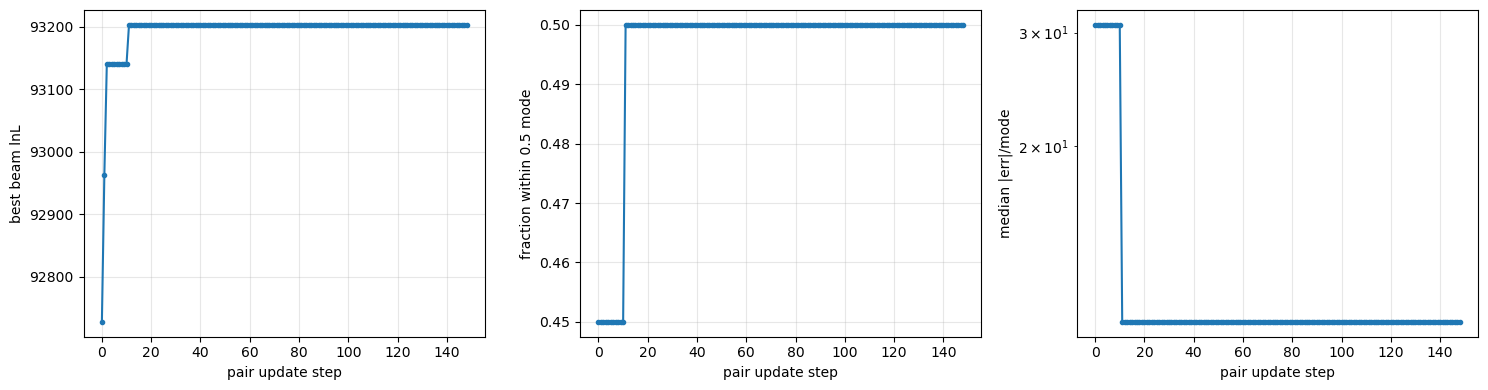

In [92]:
if "beam_history_df" in globals() and len(beam_history_df):
    best_h = beam_history_df[beam_history_df["rank"] == 0]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(best_h["step"], best_h["lnL"], ".-")
    axes[1].plot(best_h["step"], best_h["frac_within_half_mode"], ".-")
    axes[2].plot(best_h["step"], best_h["median_abs_modes"], ".-")
    axes[2].set_yscale("log")
    axes[0].set_ylabel("best beam lnL")
    axes[1].set_ylabel("fraction within 0.5 mode")
    axes[2].set_ylabel("median |err|/mode")
    for ax in axes:
        ax.set_xlabel("pair update step")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    display(best_h.tail(20))

    rows=[]
    for rank, st in enumerate(beam_states):
        rows.append(dict(rank=rank, lnL=st["lnL"], **recovery_score(st["distances"], truth_dist, sigmas, mode_spacings)))
    display(pd.DataFrame(rows))
else:
    print("Run beam optimizer first.")

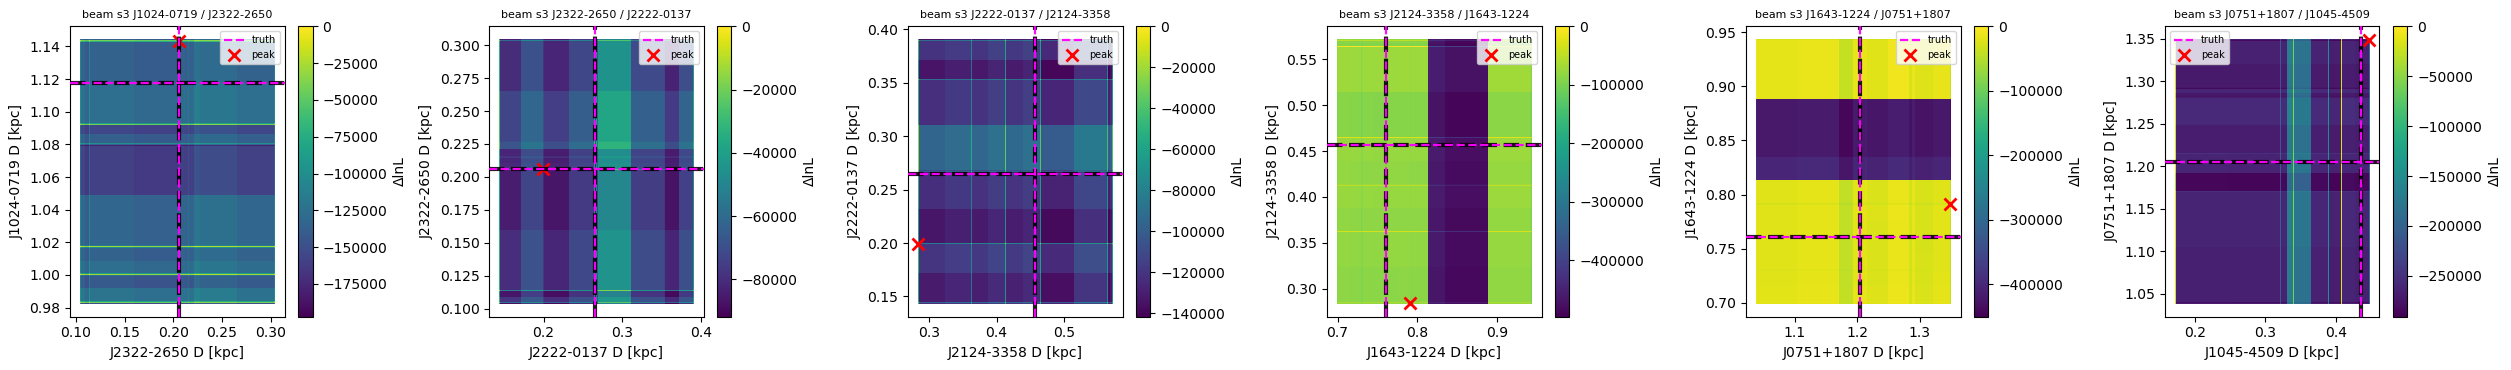

In [93]:
if "beam_pair_records" in globals() and beam_pair_records:
    records = [r for r in beam_pair_records if r.get("scan") is not None]
    n = min(len(records), 6)
    fig, axes = plt.subplots(1, n, figsize=(4.2*n, 3.8), squeeze=False)
    for ax, rec in zip(axes[0], records[-n:]):
        scan = rec["scan"]
        z = scan["lnL"] - np.nanmax(scan["lnL"])
        im = ax.pcolormesh(scan["grid_j"], scan["grid_i"], z, shading="auto", cmap="viridis")
        draw_truth_crosshair(ax, rec["truth_i"], rec["truth_j"])
        ax.plot(scan["peak_j"], scan["peak_i"], "rx", ms=8, mew=2, label="peak")
        set_pair_plot_limits(ax, scan["grid_i"], scan["grid_j"], rec["truth_i"], rec["truth_j"])
        ax.set_title(f"beam s{rec['sweep']} {rec['psr_i']} / {rec['psr_j']}", fontsize=8)
        ax.set_xlabel(f"{rec['psr_j']} D [kpc]")
        ax.set_ylabel(f"{rec['psr_i']} D [kpc]")
        ax.legend(fontsize=7)
        cb=plt.colorbar(im, ax=ax); cb.set_label("ΔlnL")
    plt.tight_layout()
else:
    print("Run beam optimizer first.")

## Beam Failure Diagnostics

Run these after candidate scan and beam optimizer. They answer:

1. Did the 1D candidate list include truth-near modes?
2. Did final beam retain truth-near distances?
3. For retained pair scans, was truth inside evaluated grid and how far below the grid peak was it?

If truth is in the grid but not peak, that may be real conditional likelihood behavior: other pulsar distances are held at current beam values, so this 2D conditional surface need not peak at truth unless the rest of the vector is also close to truth.

In [98]:
def nearest_grid_value(grid, x):
    grid = np.asarray(grid, dtype=float)
    idx = int(np.nanargmin(np.abs(grid - x)))
    return idx, float(grid[idx])


def surface_truth_diagnostics(rec):
    scan = rec.get("scan")
    if scan is None:
        return None
    gi = np.asarray(scan["grid_i"], dtype=float)
    gj = np.asarray(scan["grid_j"], dtype=float)
    z = np.asarray(scan["lnL"], dtype=float)
    ii, ti = nearest_grid_value(gi, rec["truth_i"])
    jj, tj = nearest_grid_value(gj, rec["truth_j"])
    peak_idx = np.unravel_index(np.nanargmax(z), z.shape)
    return dict(
        step=rec.get("step"),
        sweep=rec.get("sweep"),
        pair_index=rec.get("pair_index"),
        pair=f"{rec.get('psr_i')} / {rec.get('psr_j')}",
        truth_i_in_grid=bool(np.isclose(ti, rec["truth_i"], rtol=0, atol=1e-14)),
        truth_j_in_grid=bool(np.isclose(tj, rec["truth_j"], rtol=0, atol=1e-14)),
        nearest_truth_i=ti,
        nearest_truth_j=tj,
        peak_i=float(gi[peak_idx[0]]),
        peak_j=float(gj[peak_idx[1]]),
        lnL_at_nearest_truth=float(z[ii, jj]),
        lnL_peak=float(np.nanmax(z)),
        delta_lnL_truth_minus_peak=float(z[ii, jj] - np.nanmax(z)),
    )

if "candidate_df" in globals() and len(candidate_df):
    cand_summary = candidate_df.groupby("pulsar_index").agg(
        pulsar=("pulsar", "first"),
        best_abs_err_modes=("error_modes", lambda x: float(np.nanmin(np.abs(x)))),
        best_rank_near_truth=("error_modes", lambda x: int(np.nanargmin(np.abs(x)))),
        n_candidates=("rank", "count"),
    ).reset_index()
    cand_summary["truth_candidate_within_half_mode"] = cand_summary["best_abs_err_modes"] < 0.5
    display(cand_summary)
    print("candidate truth coverage:", cand_summary["truth_candidate_within_half_mode"].mean())
else:
    print("No candidate_df found.")

if "beam_states" in globals() and beam_states:
    rows=[]
    for rank, st in enumerate(beam_states):
        err_modes = (st["distances"] - truth_dist) / mode_spacings
        rows.append(dict(
            rank=rank,
            lnL=st["lnL"],
            frac_within_half_mode=float(np.mean(np.abs(err_modes) < 0.5)),
            median_abs_modes=float(np.median(np.abs(err_modes))),
            max_abs_modes=float(np.max(np.abs(err_modes))),
        ))
    display(pd.DataFrame(rows))
else:
    print("No beam_states found.")

if "beam_pair_records" in globals() and beam_pair_records:
    diag = [surface_truth_diagnostics(r) for r in beam_pair_records]
    diag = [d for d in diag if d is not None]
    surf_diag = pd.DataFrame(diag)
    display(surf_diag.tail(20))
    if len(surf_diag):
        print("truth in both grid fraction:", (surf_diag["truth_i_in_grid"] & surf_diag["truth_j_in_grid"]).mean())
        print("median ΔlnL truth-peak:", surf_diag["delta_lnL_truth_minus_peak"].median())
else:
    print("No beam_pair_records found.")

,pulsar_index,pulsar,best_abs_err_modes,best_rank_near_truth,n_candidates,truth_candidate_within_half_mode
0,0,J0437-4715,0.096077,0,12,True
1,1,J0030+0451,0.020767,0,12,True
2,2,J1744-1134,0.133709,0,12,True
3,3,J1909-3744,0.051614,0,12,True
4,4,J1022+1001,0.103436,2,12,True
5,5,J1713+0747,0.071201,0,12,True
6,6,J0711-6830,0.049762,0,12,True
7,7,J1012+5307,0.126977,3,12,True
8,8,J1730-2304,0.075296,1,12,True
9,9,J2145-0750,0.121036,5,12,True


candidate truth coverage: 0.95


,rank,lnL,frac_within_half_mode,median_abs_modes,max_abs_modes
0,0,93202.898795,0.50,10.652979,375.945684
1,1,93140.380432,0.45,30.833051,375.945684
2,2,93025.600121,0.50,10.661688,375.945684
3,3,92968.016655,0.50,10.652979,375.945684
4,4,92963.081758,0.45,30.833051,375.945684
5,5,92905.498292,0.45,30.833051,375.945684
6,6,92790.717981,0.50,10.661688,375.945684
7,7,92728.199617,0.45,30.833051,375.945684


,step,sweep,pair_index,pair,truth_i_in_grid,truth_j_in_grid,nearest_truth_i,nearest_truth_j,peak_i,peak_j,lnL_at_nearest_truth,lnL_peak,delta_lnL_truth_minus_peak
128,129,3,17,J0437-4715 / J0751+1807,False,False,0.153481,1.214168,0.153481,1.348379,79730.272173,93202.898795,-13472.626621
129,130,3,18,J0437-4715 / J1045-4509,False,False,0.153481,0.446208,0.153481,0.447052,-155830.307240,93202.898795,-249033.206035
130,131,3,19,J0030+0451 / J1744-1134,False,False,0.334157,0.406069,0.334157,0.406069,93202.898795,93202.898795,0.000000
131,132,3,20,J1744-1134 / J1909-3744,False,False,0.406069,1.155663,0.406069,1.155663,93202.898795,93202.898795,0.000000
132,133,3,21,J1909-3744 / J1022+1001,False,False,1.155663,0.704517,1.155663,0.736971,92973.100583,93202.898795,-229.798212
133,134,3,22,J1022+1001 / J1713+0747,False,False,0.704517,1.123959,0.736971,1.123959,92973.100583,93202.898795,-229.798212
134,135,3,23,J1713+0747 / J0711-6830,False,False,1.123959,0.077022,1.123959,0.077022,93202.898795,93202.898795,0.000000
135,136,3,24,J0711-6830 / J1012+5307,False,False,0.077022,0.876342,0.077022,0.821537,92077.754287,93202.898795,-1125.144507
136,137,3,25,J1012+5307 / J1730-2304,False,False,0.876342,0.536894,0.821537,0.509266,91943.675211,93202.898795,-1259.223584
137,138,3,26,J1730-2304 / J2145-0750,False,False,0.536894,0.566882,0.509266,0.683644,-32881.582871,93202.898795,-126084.481665


truth in both grid fraction: 0.0
median ΔlnL truth-peak: -229.79821179136343


conditioned on best beam
  peak: 1.3483791895947972 0.44705152576288143 lnL 93202.89879484501
  truth grid: 1.2141682233592823 0.44620765073304464 lnL -169302.93386162497
  ΔlnL truth-peak: -262505.83265647
conditioned on full truth
  peak: 1.3483791895947972 0.44705152576288143 lnL 104374.29750347018
  truth grid: 1.2141682233592823 0.44620765073304464 lnL -158131.5351529998
  ΔlnL truth-peak: -262505.83265647


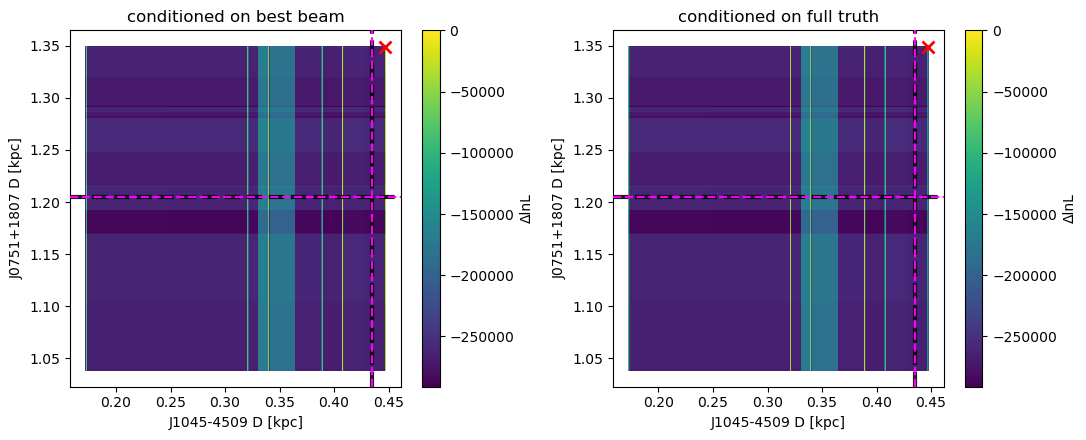

In [99]:
# Compare conditional pair surface at final best beam vs full truth vector for same pair.
# If final-best conditional surface peaks away from truth but full-truth conditional surface peaks at truth,
# then issue is global state/beam got stuck, not signal model.
COMPARE_PAIR_RECORD_INDEX = -1

if "beam_pair_records" in globals() and beam_pair_records and "beam_states" in globals() and beam_states:
    rec = [r for r in beam_pair_records if r.get("scan") is not None][COMPARE_PAIR_RECORD_INDEX]
    i, j = rec["i"], rec["j"]
    psr_i, psr_j = disco_psrs[i], disco_psrs[j]
    best_state = beam_states[0]

    # Reuse exact grid from stored beam scan.
    grid_i = rec["scan"]["grid_i"]
    grid_j = rec["scan"]["grid_j"]

    _, _, surf_best = scan_pulsar_pair_2d(
        logl_fn, best_state["values"], param_keys,
        distance_key(psr_i), distance_key(psr_j), grid_i, grid_j,
        chunk_size=CHUNK_SIZE, n_components=COMPONENTS,
    )
    _, _, surf_truth = scan_pulsar_pair_2d(
        logl_fn, truth_values, param_keys,
        distance_key(psr_i), distance_key(psr_j), grid_i, grid_j,
        chunk_size=CHUNK_SIZE, n_components=COMPONENTS,
    )

    for label, surf in [("conditioned on best beam", surf_best), ("conditioned on full truth", surf_truth)]:
        ii, _ = nearest_grid_value(grid_i, truth_dist[i])
        jj, _ = nearest_grid_value(grid_j, truth_dist[j])
        pk = np.unravel_index(np.nanargmax(surf), surf.shape)
        print(label)
        print("  peak:", grid_i[pk[0]], grid_j[pk[1]], "lnL", float(surf[pk]))
        print("  truth grid:", grid_i[ii], grid_j[jj], "lnL", float(surf[ii, jj]))
        print("  ΔlnL truth-peak:", float(surf[ii, jj] - surf[pk]))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), squeeze=False)
    for ax, surf, title in zip(axes[0], [surf_best, surf_truth], ["conditioned on best beam", "conditioned on full truth"]):
        z = surf - np.nanmax(surf)
        im = ax.pcolormesh(grid_j, grid_i, z, shading="auto", cmap="viridis")
        draw_truth_crosshair(ax, truth_dist[i], truth_dist[j])
        pk = np.unravel_index(np.nanargmax(surf), surf.shape)
        ax.plot(grid_j[pk[1]], grid_i[pk[0]], "rx", ms=9, mew=2)
        set_pair_plot_limits(ax, grid_i, grid_j, truth_dist[i], truth_dist[j])
        ax.set_title(title)
        ax.set_xlabel(f"{psr_j.name} D [kpc]")
        ax.set_ylabel(f"{psr_i.name} D [kpc]")
        cb = plt.colorbar(im, ax=ax); cb.set_label("ΔlnL")
    plt.tight_layout()
else:
    print("Need beam optimizer outputs first.")

## Convergence Diagnostics

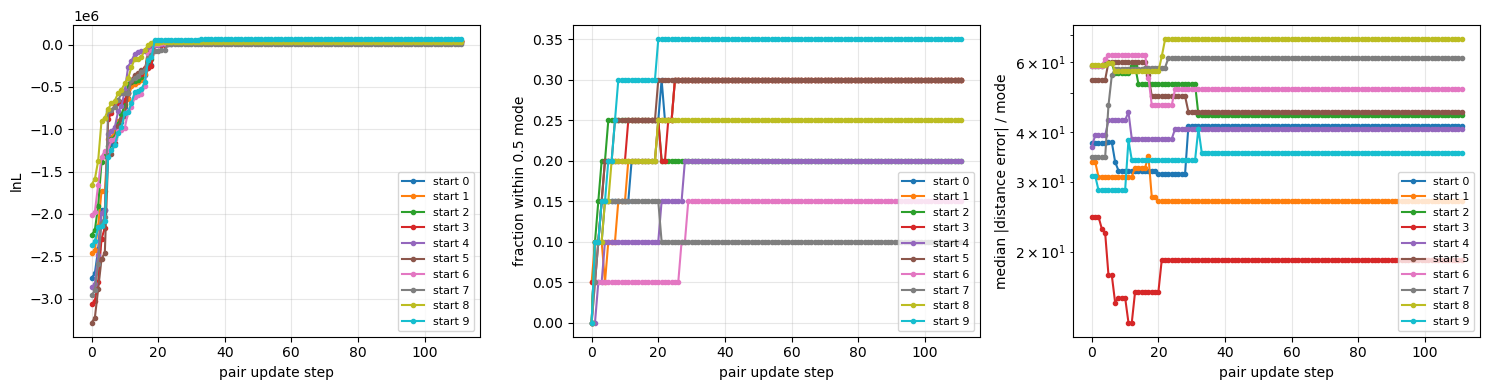

,start,sweep,pair_index,step,lnL,max_abs_kpc,median_abs_kpc,max_abs_sigma,median_abs_sigma,max_abs_modes,median_abs_modes,frac_within_half_mode,frac_within_one_mode,pair,accepted,peak_lnL,old_lnL,dlnL
1100,9,2,17,92,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J0437-4715,J0751+1807",True,61992.314748,61992.314748,0.0
1101,9,2,18,93,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J0437-4715,J1045-4509",True,61992.314748,61992.314748,0.0
1102,9,2,19,94,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J0030+0451,J1744-1134",True,61992.314748,61992.314748,0.0
1103,9,2,20,95,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J1744-1134,J1909-3744",True,61992.314748,61992.314748,0.0
1104,9,2,21,96,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J1909-3744,J1022+1001",True,61992.314748,61992.314748,0.0
1105,9,2,22,97,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J1022+1001,J1713+0747",True,61992.314748,61992.314748,0.0
1106,9,2,23,98,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J1713+0747,J0711-6830",True,61992.314748,61992.314748,0.0
1107,9,2,24,99,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J0711-6830,J1012+5307",True,61992.314748,61992.314748,0.0
1108,9,2,25,100,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J1012+5307,J1730-2304",True,61992.314748,61992.314748,0.0
1109,9,2,26,101,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35,"J1730-2304,J2145-0750",True,61992.314748,61992.314748,0.0


In [94]:
if "history_df" in globals() and len(history_df):
    plot_start_status(history_df)
    display(history_df.tail(20))
else:
    print("Run optimizer first.")

## Distance Trajectories

Shows recovered distance error after each pair update, in units of each pulsar's minimum mode spacing.

,start,lnL,max_abs_kpc,median_abs_kpc,max_abs_sigma,median_abs_sigma,max_abs_modes,median_abs_modes,frac_within_half_mode,frac_within_one_mode
9,9,61992.314748,0.100626,0.016873,3.159557,0.357086,194.636819,35.474076,0.35,0.35
2,2,48061.089171,0.077981,0.023475,3.159611,0.788910,165.979477,44.183447,0.20,0.20
1,1,47186.459744,0.187484,0.014841,2.757124,0.461781,333.256326,26.793485,0.30,0.30
5,5,45022.234233,0.106126,0.027790,3.153283,0.511400,191.891509,44.923788,0.30,0.30
3,3,38522.340082,0.098849,0.010846,3.304495,0.502539,194.013342,19.075505,0.30,0.30
8,8,35118.429245,0.132980,0.031375,4.124186,1.209925,236.373689,68.326011,0.25,0.25
0,0,29236.200734,0.102602,0.026461,4.663712,0.829105,209.648626,41.383313,0.30,0.30
6,6,29009.578625,0.187507,0.029977,2.757462,1.349190,333.297151,51.250920,0.15,0.15
4,4,17314.235229,0.133005,0.022919,3.781454,0.878284,236.419159,40.692161,0.20,0.20
7,7,12703.446080,0.091095,0.029741,2.096691,1.231049,142.944241,61.354289,0.10,0.10


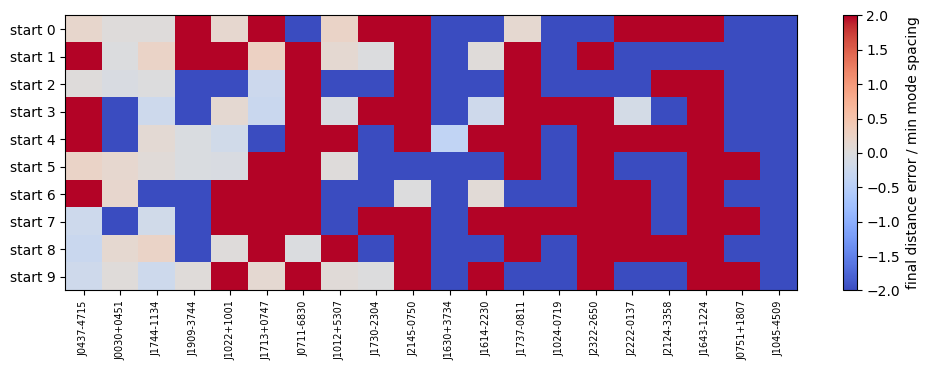

In [95]:
if "final_states" in globals() and final_states:
    final_err = np.array([(s["distances"] - truth_dist) / mode_spacings for s in final_states])
    names = [p.name for p in disco_psrs]
    fig, ax = plt.subplots(figsize=(max(10, 0.3 * len(names)), 3.8))
    im = ax.imshow(final_err, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    ax.set_yticks(range(len(final_states)))
    ax.set_yticklabels([f"start {s['start']}" for s in final_states])
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=7)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("final distance error / min mode spacing")
    plt.tight_layout()

    rows = []
    for state in final_states:
        row = {"start": state["start"], "lnL": state["lnL"], **state["score"]}
        rows.append(row)
    display(pd.DataFrame(rows).sort_values("lnL", ascending=False))
else:
    print("Run optimizer first.")

## Last Pair-Scan Surfaces

These are actual 2D likelihood windows used by optimizer. Star = injected truth for that pair. X = selected grid peak.

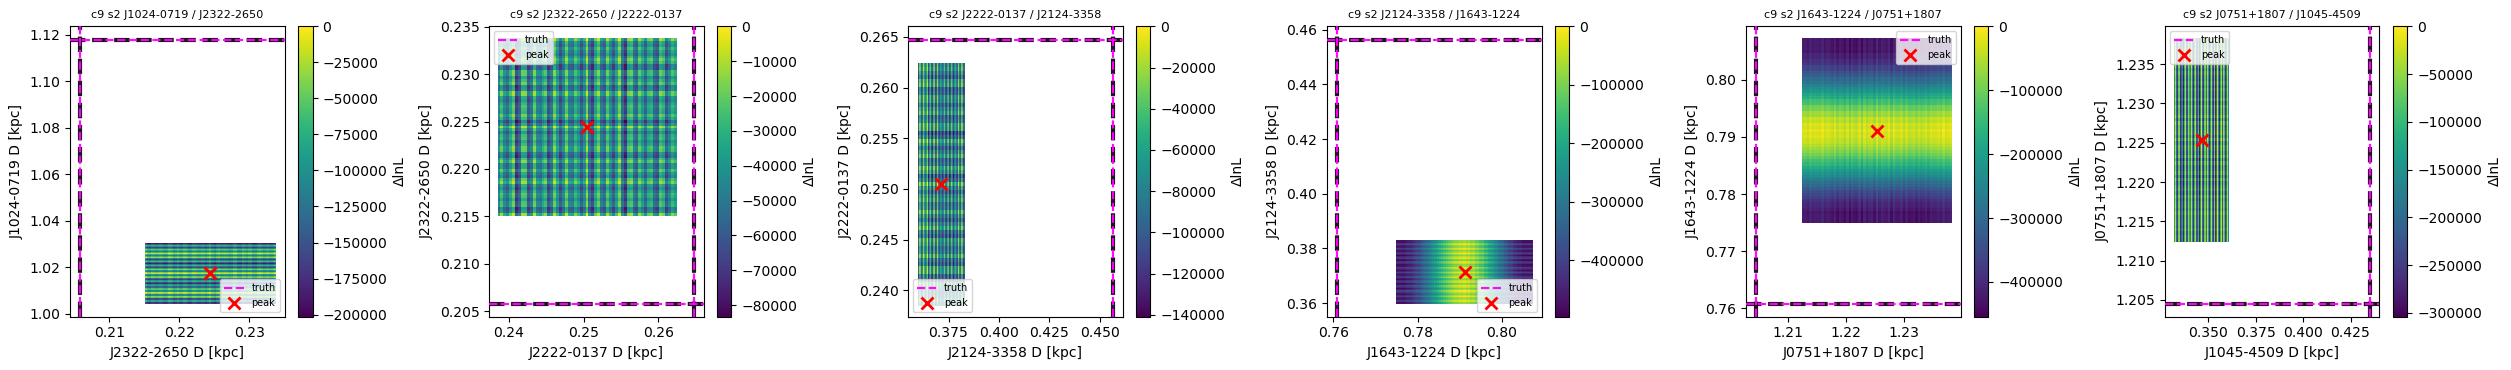

In [96]:
if "pair_records" in globals() and pair_records:
    n = min(len(pair_records), 6)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.8), squeeze=False)
    for ax, rec in zip(axes[0], pair_records[-n:]):
        scan = rec["scan"]
        z = scan["lnL"] - np.nanmax(scan["lnL"])
        im = ax.pcolormesh(scan["grid_j"], scan["grid_i"], z, shading="auto", cmap="viridis")
        draw_truth_crosshair(ax, rec["truth_i"], rec["truth_j"])
        ax.plot(scan["peak_j"], scan["peak_i"], "rx", ms=8, mew=2, label="peak")
        set_pair_plot_limits(ax, scan["grid_i"], scan["grid_j"], rec["truth_i"], rec["truth_j"])
        ax.set_title(f"c{rec['start']} s{rec['sweep']} {rec['psr_i']} / {rec['psr_j']}", fontsize=8)
        ax.set_xlabel(f"{rec['psr_j']} D [kpc]")
        ax.set_ylabel(f"{rec['psr_i']} D [kpc]")
        ax.legend(fontsize=7, loc="best")
        cb = plt.colorbar(im, ax=ax)
        cb.set_label("ΔlnL")
    plt.tight_layout()
else:
    print("Run optimizer first.")

## Inspect One Pair Surface

Use this to examine a specific retained pair scan at higher detail.

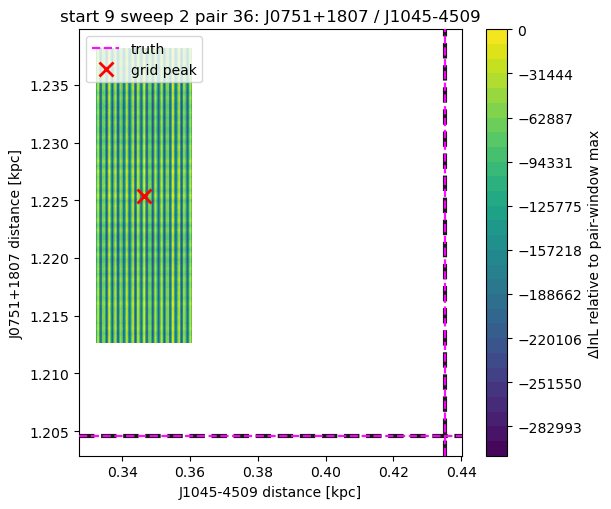

In [97]:
PAIR_RECORD_INDEX = -1

if "pair_records" in globals() and pair_records:
    rec = pair_records[PAIR_RECORD_INDEX]
    scan = rec["scan"]
    z = scan["lnL"] - np.nanmax(scan["lnL"])

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    levels = np.linspace(np.nanmin(z), 0, 30)
    im = ax.contourf(scan["grid_j"], scan["grid_i"], z, levels=levels, cmap="viridis")
    ax.contour(scan["grid_j"], scan["grid_i"], z, levels=[-10, -5, -2, -1, -0.5], colors="w", linewidths=0.8, alpha=0.8)
    draw_truth_crosshair(ax, rec["truth_i"], rec["truth_j"])
    ax.plot(scan["peak_j"], scan["peak_i"], "rx", ms=10, mew=2, label="grid peak")
    set_pair_plot_limits(ax, scan["grid_i"], scan["grid_j"], rec["truth_i"], rec["truth_j"])
    ax.legend()
    ax.set_xlabel(f"{rec['psr_j']} distance [kpc]")
    ax.set_ylabel(f"{rec['psr_i']} distance [kpc]")
    ax.set_title(f"start {rec['start']} sweep {rec['sweep']} pair {rec['pair_index']}: {rec['psr_i']} / {rec['psr_j']}")
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("ΔlnL relative to pair-window max")
    plt.tight_layout()
else:
    print("Run optimizer first.")

## One-Off Pair Scan Around Current/Truth

Useful before running full optimizer: choose two pulsars and plot local 2D likelihood surface around either truth or a random current point.

truth lnL: 105246.352
pair peak lnL: 105246.352
peak distances: 0.15347617, 0.33414942
truth distances: 0.15347617, 0.33414942


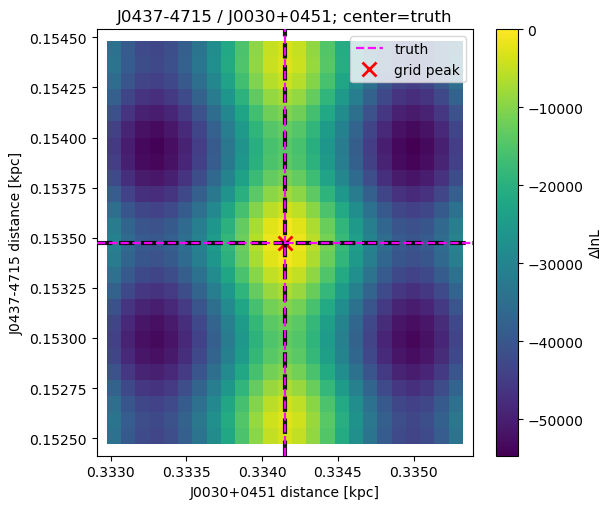

In [ ]:
SCAN_PAIR = (0, 1)
SCAN_CENTER = "truth"  # "truth" or "random"

if SCAN_CENTER == "truth":
    scan_values = np.array(truth_values, dtype=float)
else:
    scan_values = set_distances(base_values, param_keys, disco_psrs, draw_initial_distances(disco_psrs, rng, "random"))

pi, pj = SCAN_PAIR
psr_i, psr_j = disco_psrs[pi], disco_psrs[pj]
center = get_distances(scan_values, param_keys, disco_psrs)
scan = scan_pair_window_2d(
    logl_fn,
    scan_values,
    param_keys,
    psr_i,
    psr_j,
    cw_params_list,
    center_i=center[pi],
    center_j=center[pj],
    half_width_modes=HALF_WIDTH_MODES,
    points_per_mode=POINTS_PER_MODE,
    min_points=MIN_POINTS,
    chunk_size=CHUNK_SIZE,
    n_components=COMPONENTS,
    include_truth=True,
)

z = scan["lnL"] - np.nanmax(scan["lnL"])
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.pcolormesh(scan["grid_j"], scan["grid_i"], z, shading="auto", cmap="viridis")
draw_truth_crosshair(ax, truth_dist[pi], truth_dist[pj])
ax.plot(scan["peak_j"], scan["peak_i"], "rx", ms=10, mew=2, label="grid peak")
set_pair_plot_limits(ax, scan["grid_i"], scan["grid_j"], truth_dist[pi], truth_dist[pj])
ax.legend()
ax.set_xlabel(f"{psr_j.name} distance [kpc]")
ax.set_ylabel(f"{psr_i.name} distance [kpc]")
ax.set_title(f"{psr_i.name} / {psr_j.name}; center={SCAN_CENTER}")
cb = plt.colorbar(im, ax=ax)
cb.set_label("ΔlnL")
plt.tight_layout()

print(f"truth lnL: {truth_lnL:.3f}")
print(f"pair peak lnL: {scan['peak_lnL']:.3f}")
print(f"peak distances: {scan['peak_i']:.8f}, {scan['peak_j']:.8f}")
print(f"truth distances: {truth_dist[pi]:.8f}, {truth_dist[pj]:.8f}")